# Attention Mechanism in LLMs

## Why?

Before attention mechanism, there used to be a context loss problem occuring when trying to generate output sequence of text from an input sequence.

There used to be Recurrent Neural Network (RNN) which has encoder and decoder. 

Encoder reads the input sequences first to capture the meaning of entire input sequence in a hidden state.

Decoder could use encoder's hidden state while generating the output sequence.

This used to work for short sequences like sentences or paragraphs but result in limitations due to the loss of context over the long range of sequences like docs.

As the meaning of the entire input sequence was captured in one hidden state without the granularity at the level of token importance and that's the loss of context while generating output sequence because each token of output sequence is not equally related to the meaning of entire input sequence.

Therefore, invention of attention mechanism solves the context loss problem by providing the granularity of importance of context and nuanced the meaningful generation of output sequence which leads to processing long input sequence.

## Self Attention Mechanism.

**What is Self Attention?**
Attending the importance to different parts of the same input sequence hence called self attention.

Take an example input sequence "Your journey starts with one step"

Each token represented by a embedding vector.

**Goal:**
Compute a vector which is informed with the importance of each token in the sequence with respect to every other token in the sequence.

Importance is measured by a metrics called **Attention Score** and **Attention Weight**.

Informed vector is called context vector.

Therefore, implementing attention mechanism is codifying the process of going from embedding vectors of tokens sequence to context vectors of tokens sequence.

`context_vectors = attention_mechanism(embedding_vectors)`

**Recipe:**
- Compute attention scores of each token with respect to every other token.
- Compute attention weights of each token with respect to every other token.
- Compute context vectors of each token.

**Note:** _In the following cells, recipe is demystified and understood for one token first and the scaling that understanding to all other tokens._ 

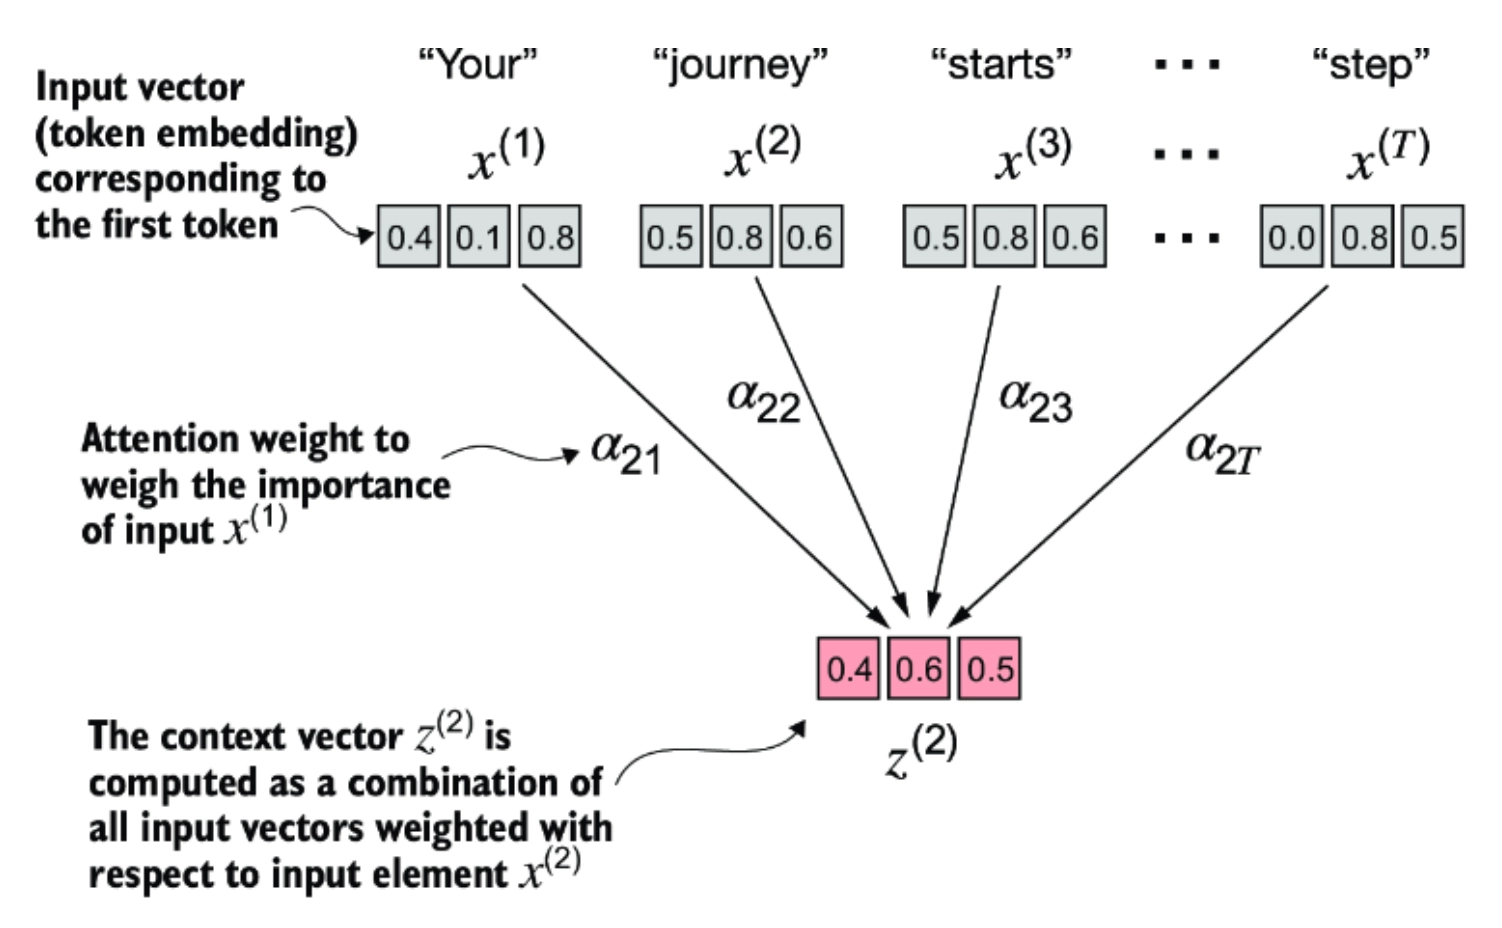

In [1]:
import torch

inputs = torch.tensor([
    [0.43, 0.15, 0.89], # Your     (x^0)
    [0.55, 0.87, 0.66], # journey  (x^1)
    [0.57, 0.85, 0.64], # starts   (x^2)
    [0.22, 0.58, 0.33], # with     (x^3)
    [0.77, 0.25, 0.10], # one      (x^4)
    [0.05, 0.80, 0.55]  # step     (x^5)
])

## Demystifying: Computing Attention Scores with respect to a Token

To start simple, let's build up the process.

- Select one token let's say "journey" or `[0.55, 0.87, 0.66]`
- Compute the importance of each token in the sequence with respect to this token.

The selected token is called `query`, with which respect to attention score will be calculated.

The mechanism to find out the importance or attention score is the dot product of vectors i.e. `dot_product(query, x_i)` because dot product is measure of similarity between two vectors in our case similarity between tokens:
- `dot_product("Your", "journey") = importance of "Your" with respect to "journey"`
- `dot_product("journey", "journey") = importance of "journey" with respect to "journey"`
- `dot_product("starts", "journey") = importance of "starts" with respect to "journey"`
- `dot_product("with", "journey") = importance of "with" with respect to "journey"`
- `dot_product("one", "journey") = importance of "one" with respect to "journey"`
- `dot_product("step", "journey") = importance of "step" with respect to "journey"`

This makes a attention scores vector having shape `[1, len(inputs)] for our example sequence [1, 6]`

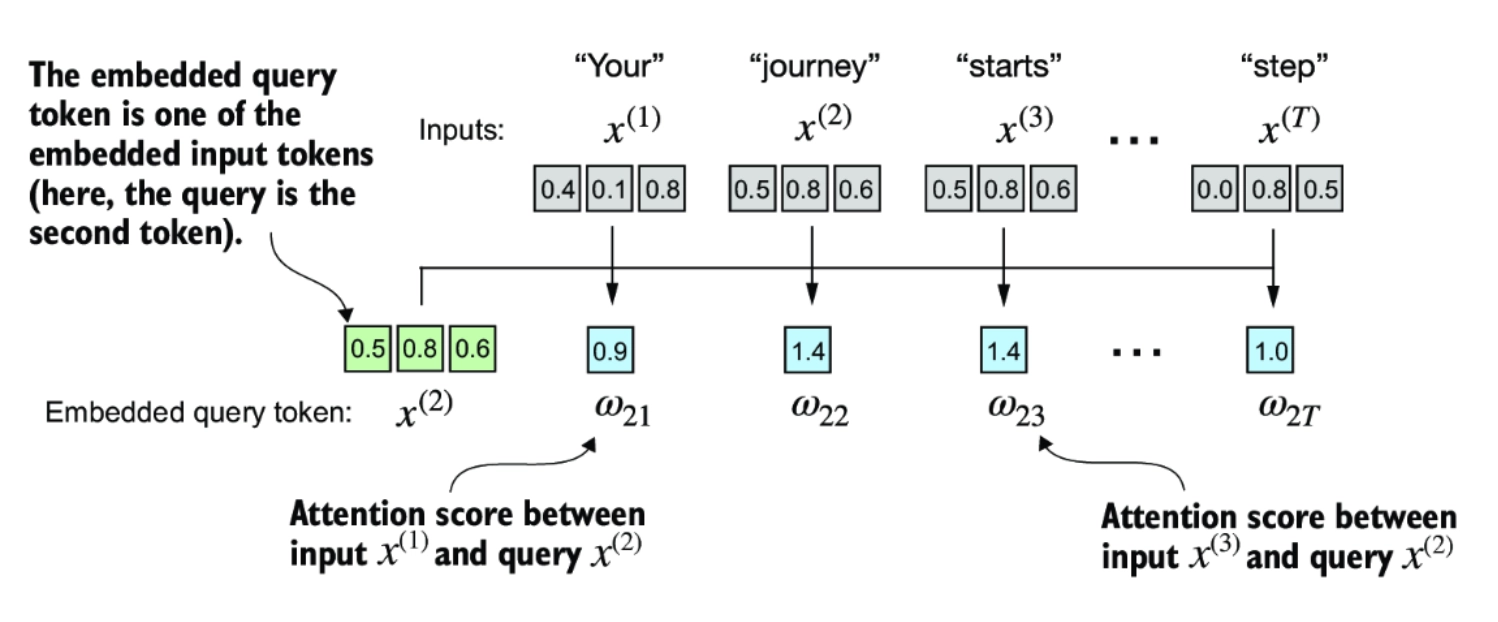



In [2]:
query = inputs[1] # "journey"
attn_scores_wrt_second_token = torch.empty(len(inputs))

for i,x_i in enumerate(inputs):
    attn_scores_wrt_second_token[i] = torch.dot(x_i, query)

attn_scores_wrt_second_token

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

## Scaling: Computing Attention Scores with respect to all Tokens

This is just the attention score of all tokens with respect to one token and this has to happen for all the tokens with respect to every other token.

That makes a attention scores matrix of [6, 6].

In [3]:
attn_scores_wrt_all_tokens = torch.empty(len(inputs), len(inputs))

for i,x_i in enumerate(inputs):
    for j,x_j in enumerate(inputs):
        attn_scores_wrt_all_tokens[i][j] = torch.dot(x_i, x_j)

attn_scores_wrt_all_tokens

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

**Note:** _Second row is same as previous result we computed with respect to second token only._

## Simplified Implementation: Computing Attention Scores with respect to all Tokens

Instead of nested loops implementation, we can represent the same thing with matrix multiplication and use pytorch implementation to do so.

In [4]:
attn_scores_wrt_all_tokens = inputs @ inputs.T
attn_scores_wrt_all_tokens

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

**Note:** _The result is exactly the same as we calculated with nested loops implementation._

## Attention Score vs Attention Weights
- **Attention score**: is a scalar value which represents importance, similarity or correlation between two tokens. It is computed by dot product.
- **Attention weight**: is a normalized vector which represents a token which is informed with all other tokens importance in the sequence relative to it. It is computed by multiply attn_scores with corresponding token and then summing all the values.

## Demystifying: Compute Attention Weights with respect to a Token

**Naive Softmax Implementation for Normalization of Attention Score to Calculate Attention Weights**
```
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
```

But pytorch provides optimized and robust implementation as well.

Check the following example of calculating attention weights with respect to second token.

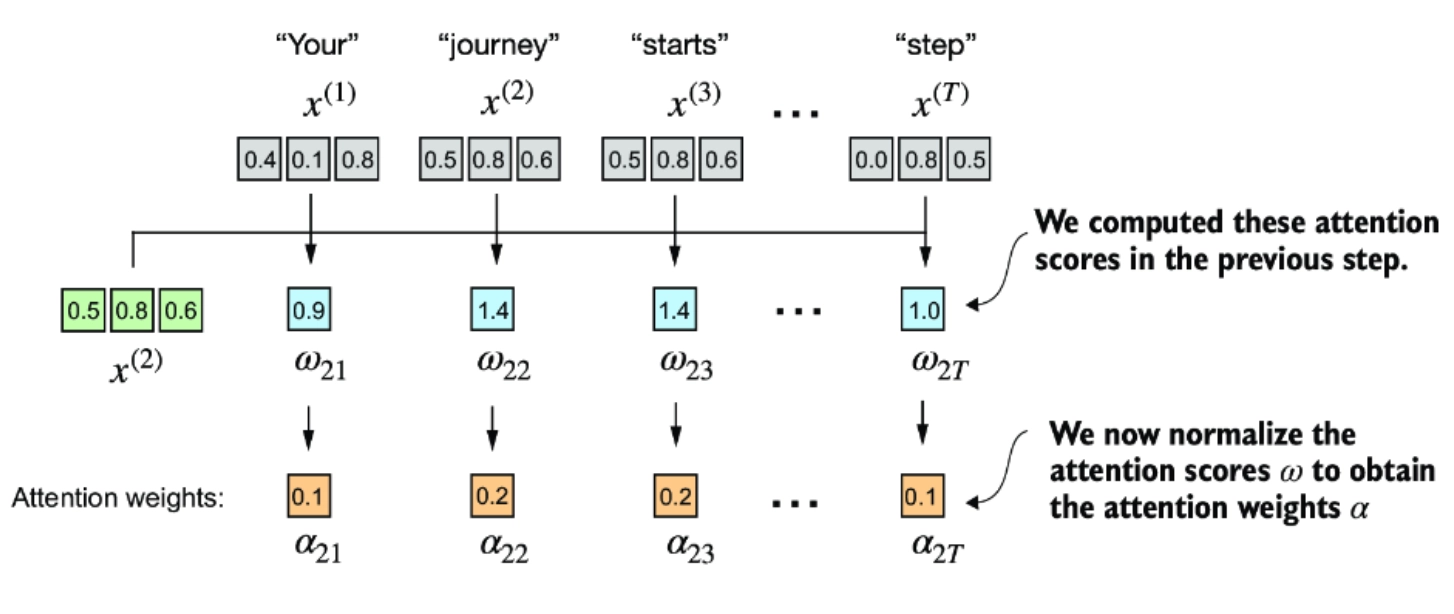

In [5]:
attn_weights_wrt_second_token = torch.softmax(attn_scores_wrt_second_token, dim=0)

print(attn_weights_wrt_second_token)
print(attn_weights_wrt_second_token.sum())

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


**Note:** _The sum of values in attention weights is 1.0 as it is an important property which comes handy while training the LLMs using mathematical optimization algorithms._

## Scaling: Compute Attention Weights with respect to all Tokens

Now, this is just the attention weight of all tokens with respect to one token and this has to happen for all the tokens with respect to every other token.

That makes a attention weights matrix of [6, 6].

In [6]:
attn_weights_wrt_all_tokens = torch.softmax(attn_scores_wrt_all_tokens, dim=1)
attn_weights_wrt_all_tokens

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

**Notes:**
- _Second row is same as previous result we computed with respect to second token only._
- _The sum of values of attention weights is 1.0 as it is an important property which comes handy while training the LLMs using mathematical optimization algorithms._

## Demystifying: Compute Context Vector of a Token

Multiply corresponding attention weights for one token to the corresponding embeddings of input tokens.

Then add them together.

The attention weights is of shape 1x6 and input embeddings of shape 6x3.

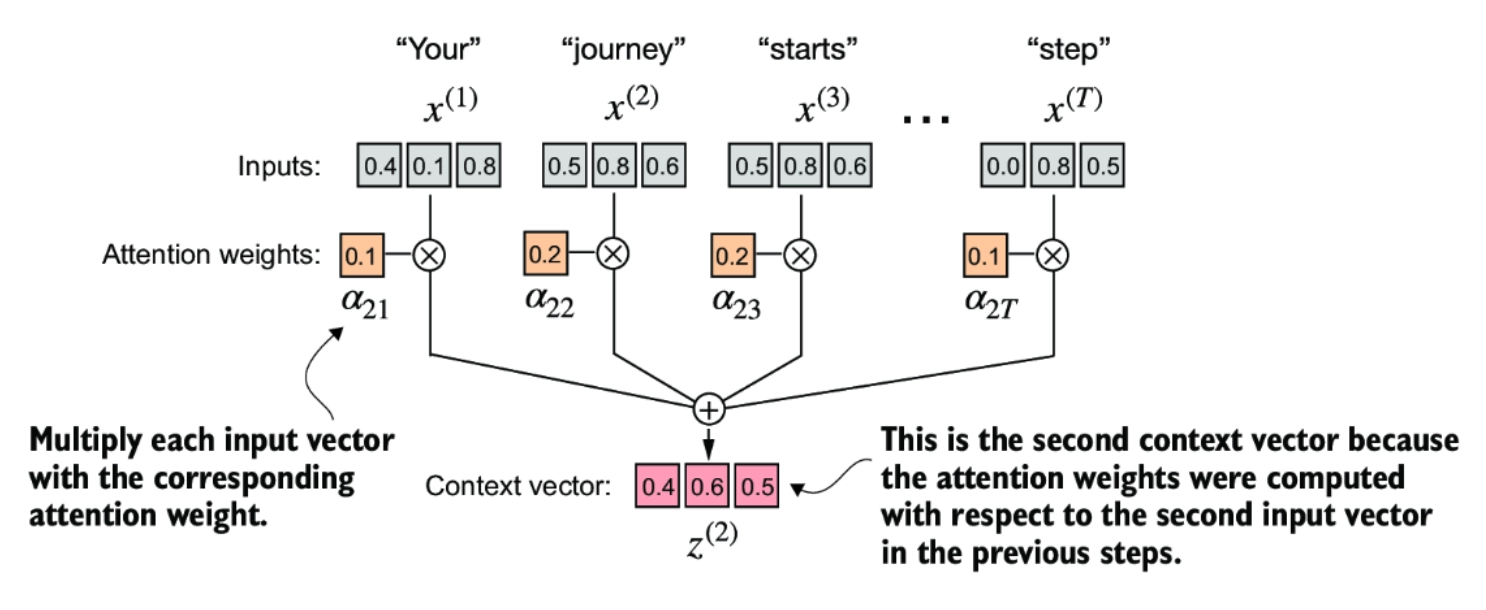

In [7]:
one_token_embedding_dim = query.shape
context_vector_of_second_token = torch.zeros(one_token_embedding_dim)

for i, x_i in enumerate(inputs):
    context_vector_of_second_token += attn_weights_wrt_second_token[i] * inputs[i]

context_vector_of_second_token

tensor([0.4419, 0.6515, 0.5683])

## Scaling: Compute Context Vector of all Tokens


In [8]:
context_vectors_of_all_tokens = torch.zeros(inputs.shape)

for i, x_i in enumerate(attn_weights_wrt_all_tokens):
    for j, x_j in enumerate(inputs):
        context_vectors_of_all_tokens[i] += attn_weights_wrt_all_tokens[i][j] * inputs[j]

context_vectors_of_all_tokens

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

**Notes:** _Second row is same as previous result we computed with respect to second token only._

## Simplified Implementation: Computing Context Vectors of all Tokens

Instead of nested loops implementation, we can represent the same thing with matrix multiplication and use pytorch implementation to do so.

In [9]:
context_vectors_of_all_tokens = attn_weights_wrt_all_tokens @ inputs

context_vectors_of_all_tokens

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

**Note:** _The result is exactly the same as we calculated with nested loops implementation._

## Stiching Everything Together for Simplest Attention Mechanism

In [10]:
import torch

# Input Sequence: "Your journey starts with one step"

inputs = torch.tensor([
    [0.43, 0.15, 0.89], # Your     (x^0)
    [0.55, 0.87, 0.66], # journey  (x^1)
    [0.57, 0.85, 0.64], # starts   (x^2)
    [0.22, 0.58, 0.33], # with     (x^3)
    [0.77, 0.25, 0.10], # one      (x^4)
    [0.05, 0.80, 0.55]  # step     (x^5)
])

def self_attention_simplest(inputs):
    attention_scores = inputs @ inputs.T
    attention_weights = torch.softmax(attention_scores, dim=1)
    context_vectors = attention_weights @ inputs

    return context_vectors

self_attention_simplest(inputs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

## Summary
- First we discussed why we need attention mechanism to solve the context loss problems with earlier solutions like RNNs.
- Then we understood how importance of each token is calculated with respect to each other using dot product mechanism.
- Each step was discussed in three levels: a. Demystifying using one token, b. Scaling to all tokens and c. Simplifying the implementation.
- Finally stiching everything together behind a simple function call abstraction that takes input sequence tokens in embeddings format and returns the context vectors which are informed vectors and together they represent a sequence which is informed about the surrounding tokens and their relative importance among each other.
- And that idea of representing relative importance of tokens in a sequence is heart & soul of modern LLMs i.e. AI.
